# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [3]:
def plot_history(history, title="Model Performance"):
    plt.figure()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

In [13]:
def build_model(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
model1 = build_model_1(X_Train.shape[1])

history1 = model1.fit(
    X_Train, y_Train,
    validation_data=(X_Test, y_Test),
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 398us/step - accuracy: 0.7912 - loss: 0.4499 - val_accuracy: 0.7950 - val_loss: 0.4398
Epoch 2/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 365us/step - accuracy: 0.7991 - loss: 0.4357 - val_accuracy: 0.7978 - val_loss: 0.4372
Epoch 3/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step - accuracy: 0.7995 - loss: 0.4341 - val_accuracy: 0.7976 - val_loss: 0.4360
Epoch 4/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.8005 - loss: 0.4327 - val_accuracy: 0.7984 - val_loss: 0.4353
Epoch 5/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 365us/step - accuracy: 0.8008 - loss: 0.4319 - val_accuracy: 0.7989 - val_loss: 0.4339
Epoch 6/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 383us/step - accuracy: 0.8009 - loss: 0.4313 - val_accuracy: 0.7993 - val_loss: 0.4334
Epoch 7/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step - accuracy: 0.8014 - loss: 0.4307 - val_accuracy: 0.7988 - val_loss: 0.4345
Epoch 8/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 360us/step - accuracy: 0.8016 -

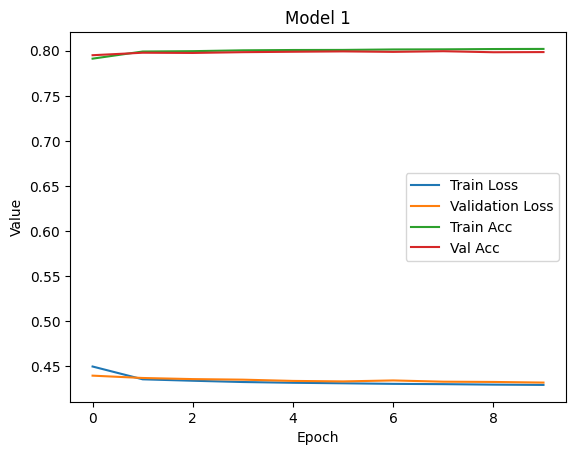

In [15]:
plot_history(history1, "Model 1")

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [16]:
def train_with_features(feature_list, model_builder):
    Xtr = np.array(Train_Sample[feature_list])
    Xte = np.array(Test_Sample[feature_list])

    model = model_builder(len(feature_list))

    history = model.fit(
        Xtr, y_Train,
        validation_data=(Xte, y_Test),
        epochs=10,
        batch_size=256,
        verbose=0
    )

    preds = model.predict(Xte).ravel()

    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_Test, preds)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, history

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 160us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 165us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 167us/step


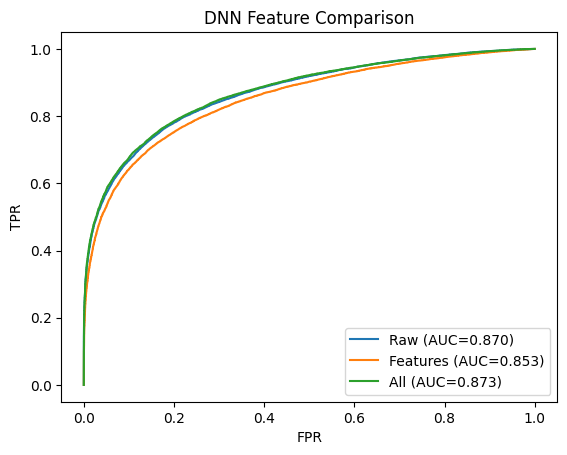

In [17]:
fpr_raw, tpr_raw, auc_raw, h_raw = train_with_features(RawNames, build_model_1)
fpr_feat, tpr_feat, auc_feat, h_feat = train_with_features(FeatureNames, build_model_1)
fpr_all, tpr_all, auc_all, h_all = train_with_features(VarNames[1:], build_model_1)

plt.figure()
plt.plot(fpr_raw, tpr_raw, label=f"Raw (AUC={auc_raw:.3f})")
plt.plot(fpr_feat, tpr_feat, label=f"Features (AUC={auc_feat:.3f})")
plt.plot(fpr_all, tpr_all, label=f"All (AUC={auc_all:.3f})")

plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("DNN Feature Comparison")
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [22]:
def build_model_2(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),   

        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
def build_model_3(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 161us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 169us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 168us/step


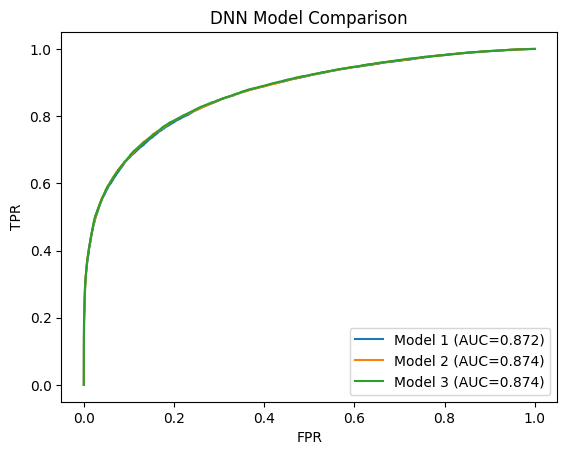

In [24]:
models = {
    "Model 1": build_model_1,
    "Model 2": build_model_2,
    "Model 3": build_model_3
}

plt.figure()

for name, builder in models.items():
    fpr, tpr, roc_auc, _ = train_with_features(VarNames[1:], builder)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("DNN Model Comparison")
plt.show()

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 162us/step


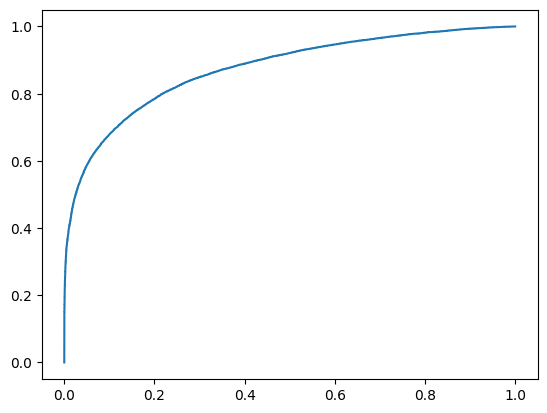

In [25]:
best_model = build_model_2(X_Train.shape[1])
best_model.fit(X_Train, y_Train, epochs=10, batch_size=256, verbose=0)

dnn_preds = best_model.predict(X_Test).ravel()

from sklearn.metrics import roc_curve, auc
fpr_dnn, tpr_dnn, _ = roc_curve(y_Test, dnn_preds)
auc_dnn = auc(fpr_dnn, tpr_dnn)

plt.plot(fpr_dnn, tpr_dnn, label=f"DNN (AUC={auc_dnn:.3f})")